In [1]:
import pandas as pd #  pandas
import seaborn as sns # seaborn
import matplotlib.pyplot as plt # matplotlib.pyplot
from pprint import pprint # pprint para visualización metadatos
from ucimlrepo import fetch_ucirepo # se importa fetch_ucilrepo
import numpy as np # numpy
import seaborn as snst # seaborn
import statsmodels.api as sm #statsmodels
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Se carga el dataset DARWIN
darwin = fetch_ucirepo(id=732)
# X (features)
x = darwin.data.features

# Y (targets)
y = darwin.data.targets

# Se concatena features y target en un mismo dataframe 'df'
df = pd.concat([x,y], axis=1)

# Análisis de ML I

En este fichero se aplican los distintos algoritmos para clasificar pacientes (P) vs sanos (H).

Se pretende estudiar que clasificador es mejor y evaluar si la explicabilidad es similar en todos los casos.

### Preparación de los datos

- Se elimina la columna `ID` que no se necesita para el análisis.
- Se separan las variables predictoras (X) de la objetivo (Y)
- Se recodifica la variable objetivo `class`: paciente (P) a 0 y sano (H) a 1
- Y se dividen los datos (X e Y) en `train` 80% y `test` 20% aleatoriamente.

In [2]:
# Se elimina la columna ID
# X = df (sin 'ID' ni 'class'), axis = 1 para cols
X = df.drop(['ID', 'class'], axis = 1)

# Y contiene 'class'
Y = df['class']

# Se codficia paciente (P) -> 1 y sano (H) -> 0
le = LabelEncoder()
Y = le.fit_transform(Y)

# Se dividen los datos en 80% para train y 20% para test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Se revisa la correcta división de los datos
print(f"Datos de entrenamiento {len(X_train)}")
print(f"Datos test {len(X_test)}")

Datos de entrenamiento 139
Datos test 35


### Estandarización de los datos

Se estandarizan los datos, pues la regresión logística es sensible a la escala, para ello se emplea `StandarScaler()` (media 0, varianza 1).

In [3]:
# StandardScaler()
scaler = StandardScaler()

# Se ajusta la estandarización con X_train
X_train_scaled = scaler.fit_transform(X_train)

# Se aplica la transformación al test
X_test_scaled = scaler.transform(X_test)

## 1. Regresión logística (LR)

### 1.1. Entrenamiento del modelo

Se entrena el modelo con los datos de entrenamiento (`X_train_scaled` y `Y_train`)

In [4]:
# Se crea el modelo
model_LR = LogisticRegression(max_iter=1000)

# Se entrena el modelo
model_LR.fit(X_train_scaled, Y_train)

print('El modelo se ha entrenado')

El modelo se ha entrenado


### 1.2. Evaluación del modelo

Se evalua el módelo con el informe de clasificación y la matriz de confusión

In [5]:
# Se realizan las predicciones
Y_pred = model_LR.predict(X_test_scaled)

# Informe de clasificación
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred))

# Matriz de confusión
print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred))

# Matriz
tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred).ravel()

# Métricas 
# Sensibilidad (capacidad para detectar los pacientes correctamente)
sensitivity = tp / (tp + fn)

# Especificdad (capacidad para dectectar los sanos correctamente)
specificity = tn / (tn + fp)

print(f"Sensibilidad: {sensitivity:.2f}")
print(f"Especificidad: {specificity:.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.69      0.65      0.67        17
           1       0.68      0.72      0.70        18

    accuracy                           0.69        35
   macro avg       0.69      0.68      0.68        35
weighted avg       0.69      0.69      0.69        35

--- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 5 13]]
Sensibilidad: 0.72
Especificidad: 0.65


**Resumen:**
- F1-score = 0.67 para sanos (H) y 0.70 para pacientes (P).
- Accuracy = 0.69
- 11 sujetos sanos (H) han sido identificados como tal (TN).
- 13 pacientes (P) han sido identificados como tal (TP).
- 5 pacientes (P) han sido identificado como sanos (H) (FN).
- 6 sanos (H) han sido identificados como pacientes (P) (FP).

### 1.3. Mejora del modelo

Se mejora el modelo ajustando los hiperparametros.

In [7]:
"""
C 
min value 0.001 
max value 5 
step 0.005
"""
c_values = np.arange(0.001, 5.005, 0.005)

# Diccionario de parámetros
param_grid = {'C': c_values}

# Búsqueda con 5 pliegues de validación cruzada
grid_search = GridSearchCV(
    LogisticRegression(max_iter=2000), 
    param_grid, 
    cv=5, 
    scoring='accuracy',
    verbose=1
)

# Se entrena el modelo
grid_search.fit(X_train_scaled, Y_train)

# Resultados
print(f"Mejor valor de C: {grid_search.best_params_['C']}")
print(f"Mejor Accuracy en CV: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
Y_pred_best = best_model.predict(X_test_scaled)

# Informe de clasificación
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_best))

# Matriz de confusión
print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_best))

# Matriz
tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred_best).ravel()

# Métricas 
# Sensibilidad (capacidad para detectar los pacientes correctamente)
sensitivity = tp / (tp + fn)

# Especificdad (capacidad para dectectar los sanos correctamente)
specificity = tn / (tn + fp)

print(f"Sensibilidad: {sensitivity:.2f}")
print(f"Especificidad: {specificity:.2f}")

Fitting 5 folds for each of 1001 candidates, totalling 5005 fits
Mejor valor de C: 0.016
Mejor Accuracy en CV: 0.9066
--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.69      0.65      0.67        17
           1       0.68      0.72      0.70        18

    accuracy                           0.69        35
   macro avg       0.69      0.68      0.68        35
weighted avg       0.69      0.69      0.69        35

--- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 5 13]]
Sensibilidad: 0.72
Especificidad: 0.65


**Resumen de la mejora del modelo:**
Los resultados obtenidos son los mismos que en el modelo anterior.
- F1-score = 0.67 para sanos (H) y 0.70 para pacientes (P).
- Accuracy = 0.69
- 11 sujetos sanos (H) han sido identificados como tal (TN).
- 13 pacientes (P) han sido identificados como tal (TP).
- 5 pacientes (P) han sido identificado como sanos (H) (FN).
- 6 sanos (H) han sido identificados como pacientes (P) (FP).
- Sensitivity = 0.72
- Specificity = 0.75

*En general, valores mas bajos que los obtenidos en el artículo Cilia et al. (2022).*

## 2. Decision Tree (DT)


In [8]:
# Se crea el modelo
tree_model = DecisionTreeClassifier(random_state=42) # random state para replicabilidad

# Se entrena el modelo
tree_model.fit(X_train, Y_train)

# Se realizan las predicciones
Y_pred_dt = tree_model.fit(X_train, Y_train).predict(X_test)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_dt))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_dt))

# TP; TN; FP; FN
tn_dt, fp_dt, fn_dt, tp_dt = confusion_matrix(Y_test, Y_pred_dt).ravel()

sensitivity_dt = tp_dt / (tp_dt + fn_dt) # sensibilidad
print(f"Sensibilidad: {sensitivity_dt:.2f}")

specificity_dt = tn_dt / (tn_dt + fp_dt) # especificidad
print(f"Especificidad: {specificity_dt:.2f}")

 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.78      0.82      0.80        17
           1       0.82      0.78      0.80        18

    accuracy                           0.80        35
   macro avg       0.80      0.80      0.80        35
weighted avg       0.80      0.80      0.80        35

--- MATRIZ DE CONFUSIÓN ---
[[14  3]
 [ 4 14]]
Sensibilidad: 0.78
Especificidad: 0.82


**Resumen:**
Accuracy = 0.80
F1 pacientes y sanos 0.80 respectivamente
Sensibilidad = 0.78
Especificidad = 0.82
- 14 sanos han sido identificados como tal (TN)
- 14 pacientes han sido identificados como tal (TP)
- 4 pacientes han sido identificados como sanos (FN)
- 3 sanos han sido identificados como pacientes (FP)

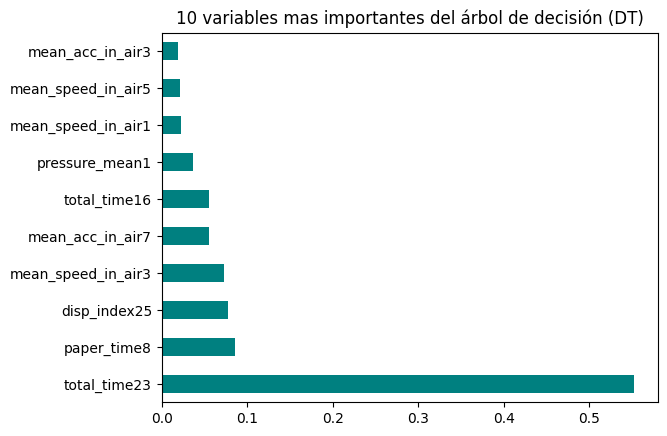

In [9]:
# Se extraen las importancias
importancias = pd.Series(tree_model.feature_importances_, index=X.columns)

# Se grafican los 10 mas importantes
importancias.nlargest(10).plot(kind="barh", color="teal")
plt.title("10 variables mas importantes del árbol de decisión (DT)") # título
plt.show()

### 2.1 Mejora del modelo

Se mejora el clasificador definiendo los hiperparámetros.

In [10]:
# max depth
max_depth_range = np.arange(2, 11, 1)

# min samples split
min_samples_split_range = np.arange(2, 6, 1)

# min samples leaf
min_samples_leaf_range = np.arange(2, 21, 2) 

param_grid_dt = {
    'max_depth': max_depth_range,
    'min_samples_split': min_samples_split_range,
    'min_samples_leaf': min_samples_leaf_range
}

# Buscador
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    verbose=1
)

# Se entrena el modelo
grid_dt.fit(X_train, Y_train)

# Mejores resultados
print(f"Mejor combinación: {grid_dt.best_params_}")
print(f"Mejor accuracy en CV: {grid_dt.best_score_}")

# Mejor árbol
best_tree = grid_dt.best_estimator_

# Resultados
Y_pred_opt = best_tree.predict(X_test)

print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_opt))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_opt))

# Sensibilidad y especificidad
tn_dt2, fp_dt2, fn_dt2, tp_dt2 = confusion_matrix(Y_test, Y_pred_opt).ravel()

print(f"Sensibilidad: {tp_dt2 / (tp_dt2 + fn_dt2):.2f}")
print(f"Especificidad: {tn_dt2 / (tn_dt2 + fp_dt2):.2f}")


Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Mejor combinación: {'max_depth': np.int64(2), 'min_samples_leaf': np.int64(18), 'min_samples_split': np.int64(2)}
Mejor accuracy en CV: 0.8637566137566137
--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        17
           1       0.75      0.67      0.71        18

    accuracy                           0.71        35
   macro avg       0.72      0.72      0.71        35
weighted avg       0.72      0.71      0.71        35

--- MATRIZ DE CONFUSIÓN ---
[[13  4]
 [ 6 12]]
Sensibilidad: 0.67
Especificidad: 0.76


Con respecto al modelo anterior, el valor de accuracy, la sensibilidad y especifidad bajan. Se recomienda el modelo anterior.

## 3. Random Forest (RF)

In [11]:
# Modelo
rf_model = RandomForestClassifier(n_estimators=100, # 100 árboles
                                  random_state=42) # resultados reproducibles

# Se entrena el modelo
rf_model.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_rf = rf_model.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN: ---") # informe de clasificación
print(classification_report(Y_test, Y_pred_rf))

# Matriz de confusión
print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_rf))

# Sensibilidad y especificidad
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(Y_test, Y_pred_rf).ravel()

print(f"Sensibilidad: {tp_rf / (tp_rf + fn_rf):.2f}")
print(f"Especificidad: {tn_rf / (tn_rf + fp_rf):.2f}")

 --- INFORME DE CLASIFICACIÓN: ---
              precision    recall  f1-score   support

           0       0.77      0.59      0.67        17
           1       0.68      0.83      0.75        18

    accuracy                           0.71        35
   macro avg       0.73      0.71      0.71        35
weighted avg       0.72      0.71      0.71        35

 --- MATRIZ DE CONFUSIÓN ---
[[10  7]
 [ 3 15]]
Sensibilidad: 0.83
Especificidad: 0.59


**Resumen:**
- Accuracy = 0.71
- F1-score para sanos (0) = 0.67
- F1-score para pacientes (1) = 0.75
- 10 sanos predichos como tal (TN).
- 15 pacientes predichos como tal (TP).
- 3 pacientes predichos como sanos (FN)
- 7 sanos predichos como pacientes (FP)
- Sensibilidad = 0.83
- Especificidad = 0.59, menor precisión a la hora de detectar a los sujetos sanos

### 3.1. Mejora del modelo

Se mejora el modelo definiendo los hiperparámetros, según Cilia et al. (2022).


In [12]:
# Se definen los hiperparámetros

rf2 = RandomForestClassifier(
    n_estimators=200, # 200 árboles
    max_depth=5, # profundidad máxima
    bootstrap=True,
    min_samples_split=2,
    min_samples_leaf=1
)

# Se entrena el modelo
rf2.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_rf2 = rf2.predict(X_test_scaled)

print("--- INFORME CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_rf2))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_rf2))

# Sensibilidad y especificidad
tn_rf2, fp_rf2, fn_rf2, tp_rf2 = confusion_matrix(Y_test, Y_pred_rf).ravel()

print(f"Sensibilidad: {tp_rf2 / (tp_rf2 + fn_rf2):.2f}")
print(f"Especificidad: {tn_rf2 / (tn_rf2 + fp_rf2):.2f}")

--- INFORME CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.87      0.76      0.81        17
           1       0.80      0.89      0.84        18

    accuracy                           0.83        35
   macro avg       0.83      0.83      0.83        35
weighted avg       0.83      0.83      0.83        35

--- MATRIZ DE CONFUSIÓN ---
[[13  4]
 [ 2 16]]
Sensibilidad: 0.83
Especificidad: 0.59


Los valores de sensibilidad y especificidad se mantienen, mientras que el valor de accuracy aumenta, por lo que se prefiere este modelo.

## 4. k-Nearest Neighbors (kNN)